In [2]:
#  import libraries
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

In [3]:
# load dataset
df = pd.read_csv("/Users/sarfarazali/Downloads/Salary_Prediction/salary_prediction.csv")
df.head()


,employee_id,age,years_experience,education_level,job_role,industry,city_type,gender,performance_rating,certifications_count,working_hours_per_week,remote_work,salary
0,1,59,33,High School,Data Analyst,Manufacturing,Tier-3,Male,1.1,6,48,1,6818944
1,2,49,26,Bachelor,Manager,Healthcare,Metro,Male,2.4,4,38,0,18329412
2,3,35,16,Bachelor,HR,Healthcare,Metro,Male,2.3,2,38,1,7106667
3,4,28,23,Master,Data Analyst,Education,Metro,Male,2.6,6,55,1,12402825
4,5,41,24,Bachelor,HR,Healthcare,Tier-3,Male,1.6,8,49,1,6316272


In [66]:
df.shape  

(1000, 13)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             1000 non-null   int64  
 1   age                     1000 non-null   int64  
 2   years_experience        1000 non-null   int64  
 3   education_level         1000 non-null   object 
 4   job_role                1000 non-null   object 
 5   industry                1000 non-null   object 
 6   city_type               1000 non-null   object 
 7   gender                  1000 non-null   object 
 8   performance_rating      1000 non-null   float64
 9   certifications_count    1000 non-null   int64  
 10  working_hours_per_week  1000 non-null   int64  
 11  remote_work             1000 non-null   int64  
 12  salary                  1000 non-null   int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 101.7+ KB


In [68]:
df.describe()

,employee_id,age,years_experience,performance_rating,certifications_count,working_hours_per_week,remote_work,salary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,500.500000,40.445000,17.292000,2.945600,4.559000,49.620000,0.466000,9.513864e+06
std,288.819436,11.499183,10.183046,1.173728,2.892557,8.592988,0.499092,6.216014e+06
min,1.000000,21.000000,0.000000,1.000000,0.000000,35.000000,0.000000,7.756600e+05
25%,250.750000,30.000000,8.750000,1.900000,2.000000,43.000000,0.000000,4.895851e+06
50%,500.500000,41.000000,17.000000,2.900000,5.000000,49.000000,0.000000,8.186118e+06
75%,750.250000,50.000000,26.000000,4.000000,7.000000,57.000000,1.000000,1.285756e+07
max,1000.000000,59.000000,34.000000,5.000000,9.000000,64.000000,1.000000,4.141005e+07


In [69]:
df.isnull().sum()

employee_id               0
age                       0
years_experience          0
education_level           0
job_role                  0
industry                  0
city_type                 0
gender                    0
performance_rating        0
certifications_count      0
working_hours_per_week    0
remote_work               0
salary                    0
dtype: int64

In [70]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["salary"] >= Q1 - 1.5*IQR) &
        (df["salary"] <= Q3 + 1.5*IQR)]

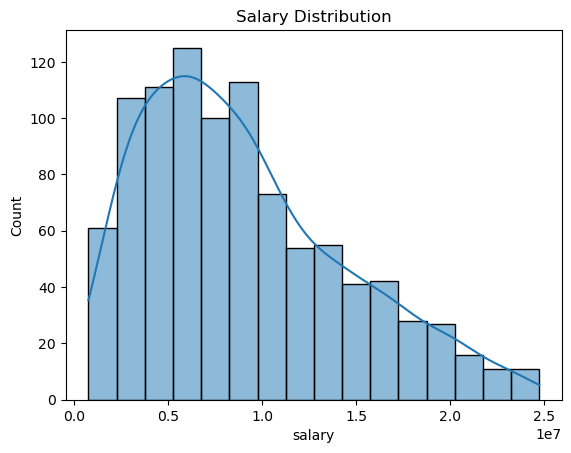

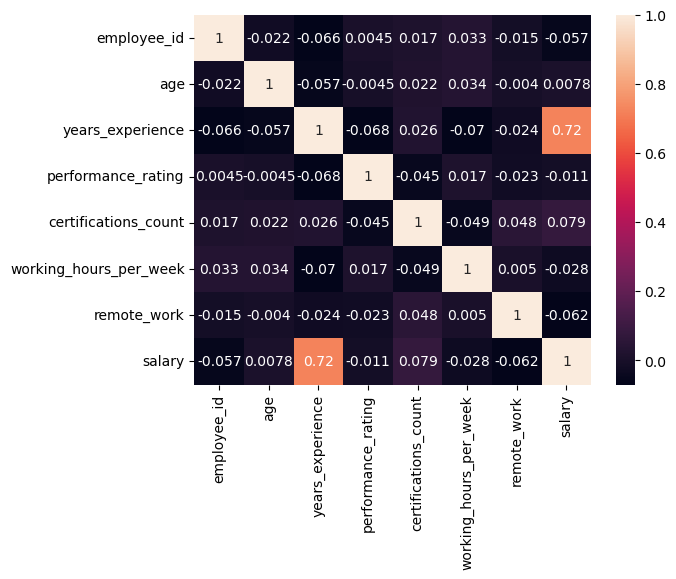

In [71]:
# Salary distribution
sns.histplot(df["salary"], kde=True)
plt.title("Salary Distribution")
plt.show()

# Correlation
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
# define features
df["log_hours"] = np.log1p(df["working_hours_per_week"])
df["productivity_score"] = df["performance_rating"] * df["log_hours"]
df["experience_level"] = np.log1p(df["years_experience"])
df["exp_productivity"] = df["years_experience"] * df["performance_rating"]
df["exp_squared"] = df["years_experience"] ** 2
df["cert_value"] = np.log1p(df["certifications_count"]) * df["performance_rating"]
df["cert_exp_ratio"] = df["certifications_count"] / (df["years_experience"] + 1)
df["hours_efficiency"] = df["performance_rating"] / np.log1p(df["working_hours_per_week"])
df["overwork_flag"] = (df["working_hours_per_week"] > 50).astype(int)
df["career_start_age"] = df["age"] - df["years_experience"]
df["early_starter"] = (df["career_start_age"] < 22).astype(int)
df["exp_hours"] = df["years_experience"] * df["working_hours_per_week"]
df["cert_hours"] = df["certifications_count"] * df["working_hours_per_week"]
df["performance_exp_cert"] = (
    df["performance_rating"] *
    df["years_experience"] *
    df["certifications_count"]
)
df["exp_per_hour"] = df["years_experience"] / (df["working_hours_per_week"] + 1)
df["cert_per_year"] = df["certifications_count"] / (df["years_experience"] + 1)



In [73]:
# Define x & y
X = df.drop(["salary","employee_id"], axis=1)
Y = np.log1p(df["salary"])

In [74]:
#  Define numerical and categorical features
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Define transformers
num_transformer = StandardScaler()  
cat_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer([
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

In [75]:
# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Display the shape of the data
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (780, 27)
Testing set shape: (195, 27)


In [76]:
# Define the pipeline
pipe = Pipeline([
    ("pre", preprocessor),
    ("lr", LinearRegression())
])

# Train the model
pipe.fit(X_train, Y_train)

,steps,"[('pre', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
# Make predictions
Y_pred_log = pipe.predict(X_test)
Y_pred = np.expm1(Y_pred_log)
Y_test_actual = np.expm1(Y_test)

In [78]:
# Evaluation
r2 = r2_score(Y_test_actual, Y_pred)
print("R2:", r2)

mae = mean_absolute_error(Y_test_actual, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test_actual, Y_pred))


print("MAE:", mae)
print("RMSE:", rmse)


R2: 0.9973131652558436
MAE: 190652.0398603187
RMSE: 248078.67890510173


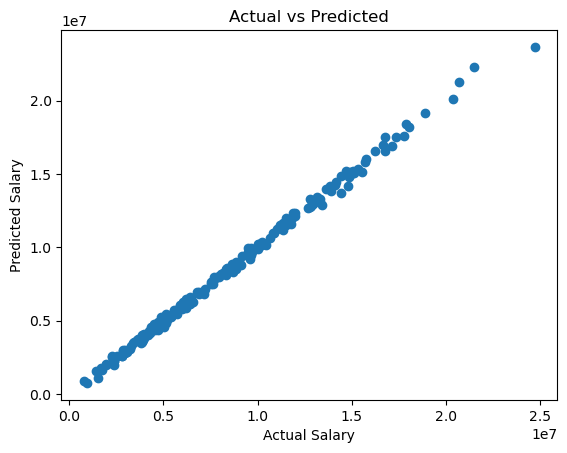

In [79]:
# ACTUAL vs PREDICTED GRAPH
plt.figure()
plt.scatter(Y_test_actual, Y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

In [80]:
# FEATURE IMPORTANCE
model = pipe.named_steps["lr"]
feature_names = pipe.named_steps["pre"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": model.coef_
})

coef_df["impact_%"] = (np.exp(coef_df["coef"]) - 1) * 100

coef_df = coef_df.sort_values(by="coef", ascending=False)
coef_df.head(10)

,feature,coef,impact_%
2,num__performance_rating,1.109863,203.394312
25,cat__education_level_PhD,0.341710,40.735261
28,cat__job_role_Manager,0.298886,34.835645
8,num__experience_level,0.296358,34.495157
36,cat__city_type_Metro,0.247495,28.081256
1,num__years_experience,0.246297,27.927892
34,cat__industry_IT,0.188264,20.715208
20,num__exp_per_hour,0.158265,17.147623
32,cat__industry_Finance,0.122101,12.986800
24,cat__education_level_Master,0.112626,11.921369
